# Strategic Forecasting Pipeline — DATATHON 2026
## Revenue & COGS Forecasting: 2023-01-01 → 2024-07-01

**Chiến lược:**
1. Feature engineering từ `sales.csv` (lags, rolling stats, calendar)
2. Prophet làm feature extractor (trend + seasonality components)
3. LightGBM + XGBoost với MAE objective + sample weighting theo thời gian
4. Ensemble 2 models: full-history + post-2019 window
5. Expanding window cross-validation
6. Tạo submission.csv theo format đề bài

**Metric:** MAE (chính), RMSE, R²


In [48]:
## ── Cell 1: Setup & Imports ──────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import json, os

# Reproducibility
SEED = 42
np.random.seed(SEED)

# LightGBM / XGBoost
import lightgbm as lgb
import xgboost as xgb

# Prophet
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("⚠️ Prophet not installed — Prophet features will be skipped.")

# Sklearn utilities
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Scipy for blend weight optimisation
from scipy.optimize import minimize

print("Libraries loaded ✓")
print(f"LightGBM  : {lgb.__version__}")
print(f"XGBoost   : {xgb.__version__}")


Libraries loaded ✓
LightGBM  : 4.6.0
XGBoost   : 3.2.0


## Giai đoạn 1 — Load & Inspect Data


In [49]:
## ── Cell 2: Load sales.csv & sample_submission.csv ───────────────────────────
BASE = Path("../data/raw")

sales = pd.read_csv(BASE / "sales.csv", parse_dates=["Date"])
sub   = pd.read_csv(BASE / "sample_submission.csv", parse_dates=["Date"])

sales = sales.sort_values("Date").reset_index(drop=True)
sub   = sub.sort_values("Date").reset_index(drop=True)

print("=== sales.csv ===")
print(f"Shape     : {sales.shape}")
print(f"Date range: {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print(f"Columns   : {list(sales.columns)}")
display(sales.head(3))
display(sales.describe())

print("\n=== sample_submission.csv ===")
print(f"Shape     : {sub.shape}")
print(f"Date range: {sub['Date'].min().date()} → {sub['Date'].max().date()}")


=== sales.csv ===
Shape     : (3833, 3)
Date range: 2012-07-04 → 2022-12-31
Columns   : ['Date', 'Revenue', 'COGS']


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84


,Date,Revenue,COGS
count,3833,3.833000e+03,3.833000e+03
mean,2017-10-02 00:00:00,4.286584e+06,3.695134e+06
min,2012-07-04 00:00:00,2.798139e+05,2.365763e+05
25%,2015-02-17 00:00:00,2.471089e+06,2.150580e+06
50%,2017-10-02 00:00:00,3.647304e+06,3.161113e+06
75%,2020-05-17 00:00:00,5.350877e+06,4.637294e+06
max,2022-12-31 00:00:00,2.090527e+07,1.653586e+07
std,NaN,2.624840e+06,2.219789e+06



=== sample_submission.csv ===
Shape     : (548, 3)
Date range: 2023-01-01 → 2024-07-01


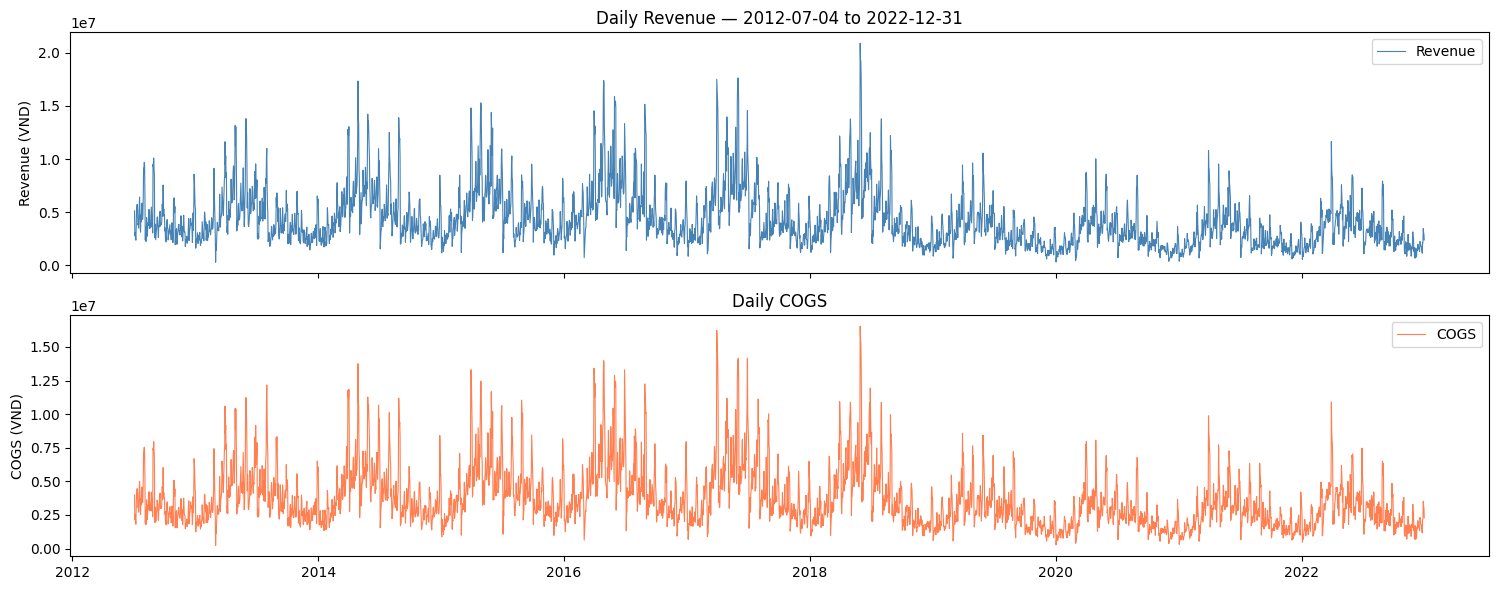

GrossProfit & ProfitMargin added.
           Revenue         COGS  GrossProfit  ProfitMargin
count      3833.00      3833.00      3833.00       3833.00
mean    4286584.03   3695134.49    591449.53          0.13
std     2624840.20   2219788.77    666196.02          0.13
min      279813.94    236576.31  -2567311.72         -0.57
25%     2471088.82   2150580.23    229274.05          0.08
50%     3647303.90   3161112.99    544554.38          0.18
75%     5350877.20   4637293.92    876080.98          0.20
max    20905271.35  16535857.67   4369413.68          0.29


In [50]:
## ── Cell 3: Quick EDA — visualise Revenue & COGS ────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].plot(sales["Date"], sales["Revenue"], lw=0.8, color="steelblue", label="Revenue")
axes[0].set_ylabel("Revenue (VND)")
axes[0].set_title("Daily Revenue — 2012-07-04 to 2022-12-31")
axes[0].legend()

axes[1].plot(sales["Date"], sales["COGS"], lw=0.8, color="coral", label="COGS")
axes[1].set_ylabel("COGS (VND)")
axes[1].set_title("Daily COGS")
axes[1].legend()

plt.tight_layout()
plt.show()

# Compute gross profit
sales["GrossProfit"] = sales["Revenue"] - sales["COGS"]
sales["ProfitMargin"] = sales["GrossProfit"] / sales["Revenue"]
print("GrossProfit & ProfitMargin added.")
print(sales[["Revenue","COGS","GrossProfit","ProfitMargin"]].describe().round(2))


## Giai đoạn 2 — Feature Engineering
Tạo lag features, rolling statistics, và calendar features từ `sales.csv` để chuẩn bị cho GBDT models.


In [51]:
## ── Cell 4: Feature Engineering function ────────────────────────────────────
def make_features(df: pd.DataFrame, target_col: str = "Revenue") -> pd.DataFrame:
    """
    Build lag + rolling + calendar features for a daily time-series DataFrame.
    df must have columns: Date (datetime), Revenue, COGS — sorted ascending.
    Returns enriched DataFrame (NaN rows for lags are kept; handled later).
    """
    df = df.copy().sort_values("Date").reset_index(drop=True)
    y = df[target_col]

    # ── Lag features ─────────────────────────────────────────────────────────
    lags = [7, 14, 21, 30, 60, 90, 182, 364, 365, 366]
    for lag in lags:
        df[f"{target_col}_lag{lag}"] = y.shift(lag)

    # Lag COGS mirrors Revenue dynamics
    cogs_lags = [7, 30, 365]
    for lag in cogs_lags:
        df[f"COGS_lag{lag}"] = df["COGS"].shift(lag)

    # ── Rolling statistics ────────────────────────────────────────────────────
    for window in [7, 14, 30, 60, 90]:
        rolled = y.shift(1).rolling(window)   # shift(1) → no leakage
        df[f"{target_col}_rmean{window}"]  = rolled.mean()
        df[f"{target_col}_rstd{window}"]   = rolled.std()

    df[f"{target_col}_rmin30"]  = y.shift(1).rolling(30).min()
    df[f"{target_col}_rmax30"]  = y.shift(1).rolling(30).max()
    # Normalised signal: today's lag7 / 30-day rolling mean
    df[f"{target_col}_norm30"] = df[f"{target_col}_lag7"] / (df[f"{target_col}_rmean30"] + 1e-8)

    # ── Calendar features ─────────────────────────────────────────────────────
    dt = df["Date"]
    df["year"]           = dt.dt.year
    df["month"]          = dt.dt.month
    df["quarter"]        = dt.dt.quarter
    df["day_of_week"]    = dt.dt.dayofweek          # 0=Mon … 6=Sun
    df["day_of_year"]    = dt.dt.dayofyear
    df["week_of_year"]   = dt.dt.isocalendar().week.astype(int)
    df["is_weekend"]     = (dt.dt.dayofweek >= 5).astype(int)
    df["is_month_start"] = dt.dt.is_month_start.astype(int)
    df["is_month_end"]   = dt.dt.is_month_end.astype(int)
    df["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)

    return df


# Apply to full train set (sales.csv)
df_feat = make_features(sales, target_col="Revenue")
# Also create COGS features (same lags for COGS target)
df_feat_cogs = make_features(sales, target_col="COGS")

print(f"Feature DataFrame shape: {df_feat.shape}")
print(f"Columns ({len(df_feat.columns)}): {list(df_feat.columns)}")


Feature DataFrame shape: (3833, 41)
Columns (41): ['Date', 'Revenue', 'COGS', 'GrossProfit', 'ProfitMargin', 'Revenue_lag7', 'Revenue_lag14', 'Revenue_lag21', 'Revenue_lag30', 'Revenue_lag60', 'Revenue_lag90', 'Revenue_lag182', 'Revenue_lag364', 'Revenue_lag365', 'Revenue_lag366', 'COGS_lag7', 'COGS_lag30', 'COGS_lag365', 'Revenue_rmean7', 'Revenue_rstd7', 'Revenue_rmean14', 'Revenue_rstd14', 'Revenue_rmean30', 'Revenue_rstd30', 'Revenue_rmean60', 'Revenue_rstd60', 'Revenue_rmean90', 'Revenue_rstd90', 'Revenue_rmin30', 'Revenue_rmax30', 'Revenue_norm30', 'year', 'month', 'quarter', 'day_of_week', 'day_of_year', 'week_of_year', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_end']


## Giai đoạn 3 — Prophet Feature Extractor
Dùng Prophet để trích xuất `trend`, `weekly_seasonality`, `yearly_seasonality`, `yhat`, `yhat_lower`, `yhat_upper`.  
Những thành phần này sẽ được đưa làm features cho LightGBM — mô hình học **phần residual** mà Prophet không giải thích được.


In [52]:
## ── Cell 5: Prophet Feature Extractor ───────────────────────────────────────
def fit_prophet_extractor(train_df: pd.DataFrame, target_col: str, horizon_dates: pd.Series):
    """
    Fit a Prophet model on train_df and return a DataFrame with decomposed
    components for ALL dates (train + test horizon).
    Returns None if Prophet is not installed.
    """
    if not PROPHET_AVAILABLE:
        print("Prophet not available — skipping.")
        return None

    prophet_df = train_df[["Date", target_col]].rename(columns={"Date": "ds", target_col: "y"})

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        seasonality_mode="multiplicative",
        uncertainty_samples=0,   # skip MC sampling → faster
    )
    m.fit(prophet_df)

    # Build future DataFrame covering train + test
    all_dates = pd.concat([train_df["Date"], horizon_dates], ignore_index=True).drop_duplicates().sort_values()
    future = pd.DataFrame({"ds": all_dates})

    forecast = m.predict(future)
    forecast = forecast.rename(columns={"ds": "Date"})

    keep_cols = ["Date", "yhat", "yhat_lower", "yhat_upper", "trend",
                 "weekly", "yearly"]
    available = [c for c in keep_cols if c in forecast.columns]
    return forecast[available].rename(columns={
        "yhat":       f"prophet_{target_col}_yhat",
        "yhat_lower": f"prophet_{target_col}_lower",
        "yhat_upper": f"prophet_{target_col}_upper",
        "trend":      f"prophet_{target_col}_trend",
        "weekly":     f"prophet_{target_col}_weekly",
        "yearly":     f"prophet_{target_col}_yearly",
    })


# ── Run for Revenue ────────────────────────────────────────────────────────
print("Fitting Prophet for Revenue …")
prophet_rev = fit_prophet_extractor(sales, "Revenue", sub["Date"])
if prophet_rev is not None:
    print(f"Prophet Revenue components: {list(prophet_rev.columns)}")
    display(prophet_rev.head(3))

# ── Run for COGS ───────────────────────────────────────────────────────────
print("\nFitting Prophet for COGS …")
prophet_cogs = fit_prophet_extractor(sales, "COGS", sub["Date"])
if prophet_cogs is not None:
    print(f"Prophet COGS components: {list(prophet_cogs.columns)}")


Fitting Prophet for Revenue …


20:48:42 - cmdstanpy - INFO - Chain [1] start processing
20:48:42 - cmdstanpy - INFO - Chain [1] done processing


Prophet Revenue components: ['Date', 'prophet_Revenue_yhat', 'prophet_Revenue_trend', 'prophet_Revenue_weekly', 'prophet_Revenue_yearly']


,Date,prophet_Revenue_yhat,prophet_Revenue_trend,prophet_Revenue_weekly,prophet_Revenue_yearly
0,2012-07-04,5.046869e+06,4.406614e+06,0.092269,0.053025
1,2012-07-05,4.857210e+06,4.407428e+06,0.055839,0.046212
2,2012-07-06,4.348243e+06,4.408242e+06,-0.055850,0.042239


20:48:42 - cmdstanpy - INFO - Chain [1] start processing



Fitting Prophet for COGS …


20:48:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet COGS components: ['Date', 'prophet_COGS_yhat', 'prophet_COGS_trend', 'prophet_COGS_weekly', 'prophet_COGS_yearly']


In [53]:
## ── Cell 6: Merge features + Prophet components ─────────────────────────────
def build_full_feature_matrix(feat_df: pd.DataFrame, prophet_df, target_col: str):
    """
    Merge lag/rolling/calendar features with Prophet components.
    Drop rows where essential lags are NaN (first ~366 rows).
    """
    merged = feat_df.copy()
    if prophet_df is not None:
        merged = merged.merge(prophet_df, on="Date", how="left")

    # Core feature columns (exclude Date, Revenue, COGS, GrossProfit, ProfitMargin)
    non_feature_cols = {"Date", "Revenue", "COGS", "GrossProfit", "ProfitMargin"}
    feature_cols = [c for c in merged.columns if c not in non_feature_cols]

    return merged, feature_cols


# Build Revenue matrix
df_rev, feat_cols_rev = build_full_feature_matrix(df_feat, prophet_rev, "Revenue")

# Build COGS matrix (df_feat_cogs already has lag/rolling for COGS)
# Merge prophet_cogs into df_feat_cogs
df_cogs_base, _ = build_full_feature_matrix(df_feat_cogs, prophet_cogs, "COGS")

print(f"Revenue feature matrix: {df_rev.shape} — {len(feat_cols_rev)} features")
print(f"Feature list: {feat_cols_rev[:10]} …")


Revenue feature matrix: (3833, 45) — 40 features
Feature list: ['Revenue_lag7', 'Revenue_lag14', 'Revenue_lag21', 'Revenue_lag30', 'Revenue_lag60', 'Revenue_lag90', 'Revenue_lag182', 'Revenue_lag364', 'Revenue_lag365', 'Revenue_lag366'] …


## Giai đoạn 4 — Train Strategy

### Sample Weighting theo thời gian
`w = exp(alpha * (year - 2012))` — dữ liệu gần hơn có trọng số cao hơn.  
Cách này tự nhiên xử lý structural break 2019–2022 mà không cần gắn tag COVID.

### Ensemble hai models
- **Model A**: Train trên toàn bộ 2012–2022 với sample weighting
- **Model B**: Train chỉ trên 2019–2022 (rolling window post-break)
- **Blend**: tối ưu hoá trọng số trên validation set 2022


Sample weight stats (alpha=0.3):
count    3833.000
mean        1.000
std         0.839
min         0.142
25%         0.348
50%         0.635
75%         1.561
max         2.844
Name: year, dtype: float64


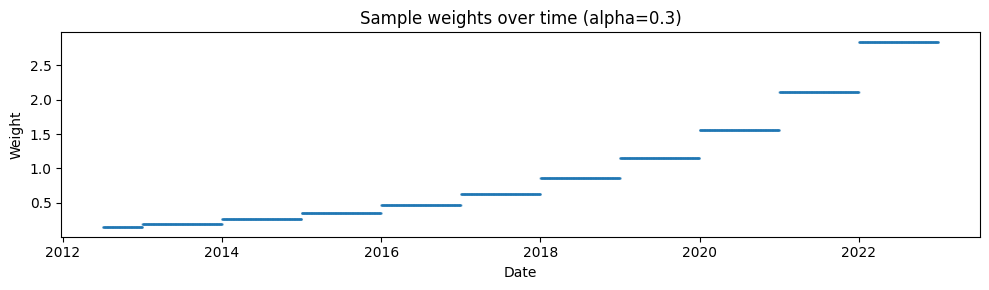

In [54]:
## ── Cell 7: Helper — sample weights ─────────────────────────────────────────
def compute_sample_weights(years: pd.Series, alpha: float = 0.3) -> np.ndarray:
    """Exponential recency weighting: w = exp(alpha * (year - min_year))."""
    min_year = years.min()
    weights = np.exp(alpha * (years - min_year))
    return weights / weights.mean()   # normalise so mean weight = 1


# Preview weight distribution
sample_years = df_rev["year"]
w_preview = compute_sample_weights(sample_years, alpha=0.3)
print("Sample weight stats (alpha=0.3):")
print(pd.Series(w_preview).describe().round(3))

fig, ax = plt.subplots(figsize=(10, 3))
ax.scatter(df_rev["Date"], w_preview, s=0.5, alpha=0.4)
ax.set_title("Sample weights over time (alpha=0.3)")
ax.set_xlabel("Date"); ax.set_ylabel("Weight")
plt.tight_layout(); plt.show()


In [55]:
## ── Cell 8: LightGBM & XGBoost train helpers ─────────────────────────────────
LGBM_PARAMS = {
    "objective"       : "regression_l1",   # MAE directly
    "metric"          : "mae",
    "num_leaves"      : 95,
    "learning_rate"   : 0.02,
    "min_child_samples": 30,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq"    : 5,
    "lambda_l1"       : 0.1,
    "lambda_l2"       : 0.1,
    "n_estimators"    : 2000,
    "n_jobs"          : -1,
    "random_state"    : SEED,
    "verbose"         : -1,
}

XGB_PARAMS = {
    "objective"           : "reg:absoluteerror",  # MAE directly
    "eval_metric"         : "mae",
    "n_estimators"        : 2000,
    "learning_rate"       : 0.02,
    "max_depth"           : 6,
    "subsample"           : 0.8,
    "colsample_bytree"    : 0.8,
    "min_child_weight"    : 20,
    "reg_alpha"           : 0.1,
    "reg_lambda"          : 0.5,
    "early_stopping_rounds": 100,   # XGBoost >= 1.6: pass in constructor, not fit()
    "n_jobs"              : -1,
    "random_state"        : SEED,
    "verbosity"           : 0,
}


def train_lgbm(X_train, y_train, w_train, X_val, y_val):
    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    # LightGBM >= 4.7: eval_set deprecated → use eval_X / eval_y
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_X=X_val,
        eval_y=y_val,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)],
    )
    return model


def train_xgb(X_train, y_train, w_train, X_val, y_val):
    model = xgb.XGBRegressor(**XGB_PARAMS)
    # early_stopping_rounds is in constructor (XGBoost >= 1.6); eval_set still in fit()
    model.fit(
        X_train, y_train,
        sample_weight=w_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    return model


def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:30s}  MAE={mae:,.0f}  RMSE={rmse:,.0f}  R²={r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2}


print("Train helpers defined ✓")


Train helpers defined ✓


## Giai đoạn 5 — Expanding Window Cross-Validation

```
Train set:  2012-07-04 → 2020-12-31
Val fold 1: 2021-01-01 → 2021-06-30  (6 tháng)
Val fold 2: 2021-07-01 → 2021-12-31  (6 tháng)
Val fold 3: 2022-01-01 → 2022-06-30  (6 tháng)
Val fold 4: 2022-07-01 → 2022-12-31  (6 tháng — gần test nhất, weight cao nhất)
```


In [56]:
## ── Cell 9: Cross-validation for Revenue ─────────────────────────────────────
# Validation folds
CV_FOLDS = [
    ("2021-01-01", "2021-06-30", 1.0),
    ("2021-07-01", "2021-12-31", 1.5),
    ("2022-01-01", "2022-06-30", 2.0),
    ("2022-07-01", "2022-12-31", 3.0),   # closest to test → highest weight
]

TARGET_COL = "Revenue"
ALPHA_WEIGHT = 0.3   # tune this if needed

# Drop rows where lag features are NaN
df_train_full = df_rev.dropna(subset=[c for c in feat_cols_rev if "lag" in c or "rmean" in c]).copy()

cv_results = []
fold_lgbm_models = []
fold_xgb_models  = []

# LightGBM compatibility patch (old versions don't support eval_X/eval_y)
def train_lgbm(X_train, y_train, w_train, X_val, y_val):
    model = lgb.LGBMRegressor(**LGBM_PARAMS)
    try:
        # Newer LightGBM API
        model.fit(
            X_train, y_train,
            sample_weight=w_train,
            eval_X=X_val,
            eval_y=y_val,
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)],
        )
    except TypeError:
        # Older LightGBM API
        model.fit(
            X_train, y_train,
            sample_weight=w_train,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(-1)],
        )
    return model

for val_start, val_end, fold_weight in CV_FOLDS:
    mask_val   = (df_train_full["Date"] >= val_start) & (df_train_full["Date"] <= val_end)
    mask_train = df_train_full["Date"] < val_start

    X_tr = df_train_full.loc[mask_train, feat_cols_rev].fillna(0)
    y_tr = df_train_full.loc[mask_train, TARGET_COL]
    w_tr = compute_sample_weights(df_train_full.loc[mask_train, "year"], alpha=ALPHA_WEIGHT)

    X_val = df_train_full.loc[mask_val, feat_cols_rev].fillna(0)
    y_val = df_train_full.loc[mask_val, TARGET_COL]

    print(f"\n── Fold {val_start} → {val_end} | train={mask_train.sum()} | val={mask_val.sum()} ──")

    lgbm_m = train_lgbm(X_tr, y_tr, w_tr, X_val, y_val)
    xgb_m  = train_xgb(X_tr, y_tr, w_tr, X_val, y_val)

    pred_lgbm = lgbm_m.predict(X_val)
    pred_xgb  = xgb_m.predict(X_val)
    pred_blend = 0.6 * pred_lgbm + 0.4 * pred_xgb

    res_lgbm  = evaluate(y_val, pred_lgbm,  f"  LGBM  {val_start[:7]}")
    res_xgb   = evaluate(y_val, pred_xgb,   f"  XGB   {val_start[:7]}")
    res_blend = evaluate(y_val, pred_blend, f"  Blend {val_start[:7]}")

    cv_results.append({
        "fold": val_start, "weight": fold_weight,
        "lgbm_mae": res_lgbm["mae"],  "xgb_mae": res_xgb["mae"],
        "blend_mae": res_blend["mae"],
    })
    fold_lgbm_models.append(lgbm_m)
    fold_xgb_models.append(xgb_m)

cv_df = pd.DataFrame(cv_results)
# Weighted average MAE
for col in ["lgbm_mae", "xgb_mae", "blend_mae"]:
    wmae = (cv_df[col] * cv_df["weight"]).sum() / cv_df["weight"].sum()
    print(f"\nWeighted-avg {col}: {wmae:,.0f}")



── Fold 2021-01-01 → 2021-06-30 | train=2737 | val=181 ──
  LGBM  2021-01                 MAE=778,209  RMSE=1,139,789  R²=0.6389
  XGB   2021-01                 MAE=732,037  RMSE=1,079,573  R²=0.6760
  Blend 2021-01                 MAE=757,624  RMSE=1,112,952  R²=0.6557

── Fold 2021-07-01 → 2021-12-31 | train=2918 | val=184 ──
  LGBM  2021-07                 MAE=485,396  RMSE=669,398  R²=0.5613
  XGB   2021-07                 MAE=482,900  RMSE=662,562  R²=0.5703
  Blend 2021-07                 MAE=481,875  RMSE=664,737  R²=0.5674

── Fold 2022-01-01 → 2022-06-30 | train=3102 | val=181 ──
  LGBM  2022-01                 MAE=802,782  RMSE=1,088,460  R²=0.6433
  XGB   2022-01                 MAE=740,536  RMSE=998,582  R²=0.6998
  Blend 2022-01                 MAE=773,385  RMSE=1,048,119  R²=0.6693

── Fold 2022-07-01 → 2022-12-31 | train=3283 | val=184 ──
  LGBM  2022-07                 MAE=584,958  RMSE=842,094  R²=0.5389
  XGB   2022-07                 MAE=583,509  RMSE=833,604  R²=0.

In [57]:
## ── Cell 10: Final models — Model A (full 2012-2022) + Model B (2019-2022) ───
print("=== Model A: full history 2012-2022 ===")
mask_all = df_train_full["Date"] <= "2022-12-31"
# Use last 6 months of 2022 as internal validation for early stopping
mask_final_val = (df_train_full["Date"] >= "2022-07-01") & (df_train_full["Date"] <= "2022-12-31")
mask_final_tr  = (df_train_full["Date"] < "2022-07-01") & mask_all

X_A_tr = df_train_full.loc[mask_final_tr, feat_cols_rev].fillna(0)
y_A_tr = df_train_full.loc[mask_final_tr, TARGET_COL]
w_A_tr = compute_sample_weights(df_train_full.loc[mask_final_tr, "year"], alpha=ALPHA_WEIGHT)
X_A_val = df_train_full.loc[mask_final_val, feat_cols_rev].fillna(0)
y_A_val = df_train_full.loc[mask_final_val, TARGET_COL]

lgbm_A = train_lgbm(X_A_tr, y_A_tr, w_A_tr, X_A_val, y_A_val)
xgb_A  = train_xgb(X_A_tr, y_A_tr, w_A_tr, X_A_val, y_A_val)
evaluate(y_A_val, lgbm_A.predict(X_A_val), "Model A LGBM val2022H2")
evaluate(y_A_val, xgb_A.predict(X_A_val),  "Model A XGB  val2022H2")

print("\n=== Model B: post-break 2019-2022 ===")
mask_B = (df_train_full["Date"] >= "2019-01-01") & (df_train_full["Date"] < "2022-07-01")
X_B_tr = df_train_full.loc[mask_B, feat_cols_rev].fillna(0)
y_B_tr = df_train_full.loc[mask_B, TARGET_COL]
# Equal weight for Model B (all post-break regime)
w_B_tr = np.ones(len(y_B_tr))

lgbm_B = train_lgbm(X_B_tr, y_B_tr, w_B_tr, X_A_val, y_A_val)
xgb_B  = train_xgb(X_B_tr, y_B_tr, w_B_tr, X_A_val, y_A_val)
evaluate(y_A_val, lgbm_B.predict(X_A_val), "Model B LGBM val2022H2")
evaluate(y_A_val, xgb_B.predict(X_A_val),  "Model B XGB  val2022H2")


=== Model A: full history 2012-2022 ===
Model A LGBM val2022H2          MAE=584,958  RMSE=842,094  R²=0.5389
Model A XGB  val2022H2          MAE=583,509  RMSE=833,604  R²=0.5481

=== Model B: post-break 2019-2022 ===
Model B LGBM val2022H2          MAE=594,915  RMSE=867,828  R²=0.5102
Model B XGB  val2022H2          MAE=600,665  RMSE=883,840  R²=0.4920


{'mae': 600664.5000000001,
 'rmse': np.float64(883839.723185195),
 'r2': 0.4920011444373653}

In [58]:
## ── Cell 11: Optimise ensemble blend weights on val2022H2 ────────────────────
preds_val = {
    "lgbm_A": lgbm_A.predict(X_A_val),
    "xgb_A" : xgb_A.predict(X_A_val),
    "lgbm_B": lgbm_B.predict(X_A_val),
    "xgb_B" : xgb_B.predict(X_A_val),
}
y_true_val = y_A_val.values

def blend_mae(w):
    """Objective: weighted blend MAE. w must sum to 1."""
    w = np.array(w)
    w = np.abs(w) / np.abs(w).sum()   # project to simplex
    pred = sum(w[i] * list(preds_val.values())[i] for i in range(4))
    return mean_absolute_error(y_true_val, pred)

# Initial equal weights
w0 = [0.25, 0.25, 0.25, 0.25]
result = minimize(blend_mae, w0, method="Nelder-Mead",
                  options={"maxiter": 2000, "xatol": 1e-6})

raw_w = np.abs(result.x)
opt_weights = raw_w / raw_w.sum()
print("Optimised blend weights:")
for name, w in zip(preds_val.keys(), opt_weights):
    print(f"  {name}: {w:.4f}")

blend_pred_val = sum(opt_weights[i] * list(preds_val.values())[i] for i in range(4))
evaluate(y_true_val, blend_pred_val, "Optimised blend val2022H2")


Optimised blend weights:
  lgbm_A: 0.2898
  xgb_A: 0.5142
  lgbm_B: 0.1960
  xgb_B: 0.0000
Optimised blend val2022H2       MAE=579,792  RMSE=837,689  R²=0.5437


{'mae': 579792.0577690593,
 'rmse': np.float64(837689.1263429419),
 'r2': 0.543667440441193}

## Giai đoạn 6 — Recursive Multi-Step Forecasting
Dự báo 548 ngày (2023-01-01 → 2024-07-01) bằng chiến lược **recursive**:  
- Tại mỗi bước t, dùng predicted values của các bước trước để tạo lag features  
- Chỉ dùng lags ≥ 7 để giảm cascade error

**Thực hiện cho cả Revenue và COGS song song.**


In [59]:
## ── Cell 12: Recursive forecaster ──────────────────────────────────────────
def recursive_forecast(
    history_df: pd.DataFrame,   # full train DataFrame with Date + target_col
    models: list,               # list of (model, weight) tuples
    feat_cols: list,
    target_col: str,
    future_dates: pd.Series,
    prophet_future: pd.DataFrame = None,
) -> np.ndarray:
    """
    Iteratively predict future_dates one day at a time.
    At each step, append the prediction to history and rebuild lag features.
    """
    # Working copy — store as Series indexed by Date for fast lookup
    hist = history_df[["Date", target_col]].copy().set_index("Date")[target_col]

    # Also keep COGS history (needed for COGS_lag features if present)
    if "COGS" in history_df.columns and target_col == "Revenue":
        cogs_hist = history_df.set_index("Date")["COGS"]
    else:
        cogs_hist = None

    predictions = []

    for dt in future_dates:
        # Build a single-row feature dict
        row = {"Date": dt}
        row["year"]           = dt.year
        row["month"]          = dt.month
        row["quarter"]        = (dt.month - 1) // 3 + 1
        row["day_of_week"]    = dt.dayofweek
        row["day_of_year"]    = dt.timetuple().tm_yday
        row["week_of_year"]   = dt.isocalendar()[1]
        row["is_weekend"]     = int(dt.weekday() >= 5)
        row["is_month_start"] = int(dt.day == 1)
        row["is_month_end"]   = int((dt + pd.Timedelta(days=1)).day == 1)
        row["is_quarter_end"] = int(dt.month in [3, 6, 9, 12] and row["is_month_end"])

        # Lag features
        lags = [7, 14, 21, 30, 60, 90, 182, 364, 365, 366]
        for lag in lags:
            past_date = dt - pd.Timedelta(days=lag)
            row[f"{target_col}_lag{lag}"] = hist.get(past_date, np.nan)

        # COGS lags (if available)
        if cogs_hist is not None:
            for lag in [7, 30, 365]:
                past_date = dt - pd.Timedelta(days=lag)
                row[f"COGS_lag{lag}"] = cogs_hist.get(past_date, np.nan)

        # Rolling statistics (from history)
        for window in [7, 14, 30, 60, 90]:
            past_vals = []
            for d in range(1, window + 1):
                pdate = dt - pd.Timedelta(days=d)
                v = hist.get(pdate, np.nan)
                if not np.isnan(v):
                    past_vals.append(v)
            if len(past_vals) >= 3:
                row[f"{target_col}_rmean{window}"] = np.mean(past_vals)
                row[f"{target_col}_rstd{window}"]  = np.std(past_vals)
            else:
                row[f"{target_col}_rmean{window}"] = np.nan
                row[f"{target_col}_rstd{window}"]  = np.nan

        past30 = [hist.get(dt - pd.Timedelta(days=d), np.nan) for d in range(1, 31)]
        past30 = [v for v in past30 if not np.isnan(v)]
        row[f"{target_col}_rmin30"] = np.min(past30) if past30 else np.nan
        row[f"{target_col}_rmax30"] = np.max(past30) if past30 else np.nan
        row[f"{target_col}_norm30"] = (row.get(f"{target_col}_lag7", np.nan) /
                                       (row.get(f"{target_col}_rmean30", np.nan) + 1e-8))

        # Prophet features
        if prophet_future is not None:
            prophet_row = prophet_future[prophet_future["Date"] == dt]
            if not prophet_row.empty:
                for c in prophet_future.columns:
                    if c != "Date":
                        row[c] = prophet_row.iloc[0][c]

        # Build feature vector
        X_row = pd.DataFrame([row])[feat_cols].fillna(0)

        # Ensemble prediction
        pred = sum(m.predict(X_row)[0] * w for m, w in models)
        pred = max(pred, 0)   # floor at 0

        predictions.append(pred)
        hist[dt] = pred   # append to history for next step

    return np.array(predictions)


print("Recursive forecaster defined ✓")


Recursive forecaster defined ✓


In [60]:
## ── Cell 13: Run Revenue forecast ──────────────────────────────────────────
# Retrain final models on entire 2012-2022 data (no held-out val needed now)
# We already have lgbm_A, xgb_A, lgbm_B, xgb_B — use optimised weights

models_rev = [
    (lgbm_A, opt_weights[0]),
    (xgb_A,  opt_weights[1]),
    (lgbm_B, opt_weights[2]),
    (xgb_B,  opt_weights[3]),
]

future_dates = sub["Date"].tolist()

print(f"Running recursive Revenue forecast for {len(future_dates)} days …")
print("This may take a few minutes.")

rev_preds = recursive_forecast(
    history_df   = sales,
    models       = models_rev,
    feat_cols    = feat_cols_rev,
    target_col   = "Revenue",
    future_dates = future_dates,
    prophet_future = prophet_rev,
)

print(f"Revenue forecasts computed: {len(rev_preds)} values")
print(f"  min={rev_preds.min():,.0f}  max={rev_preds.max():,.0f}  mean={rev_preds.mean():,.0f}")


Running recursive Revenue forecast for 548 days …
This may take a few minutes.
Revenue forecasts computed: 548 values
  min=1,341,065  max=6,384,332  mean=3,353,581


In [61]:
## ── Cell 14: Train & forecast COGS ──────────────────────────────────────────
# Re-use same pipeline but for COGS target
# df_feat_cogs already has all features including Prophet components (from Cell 6)
# So we can use it directly
df_cogs_full = df_feat_cogs.copy()

non_feature_cols_c = {"Date", "Revenue", "COGS", "GrossProfit", "ProfitMargin"}
feat_cols_cogs = [c for c in df_cogs_full.columns if c not in non_feature_cols_c]

df_cogs_full_clean = df_cogs_full.dropna(
    subset=[c for c in feat_cols_cogs if "lag" in c or "rmean" in c]
).copy()

# Train/val split for COGS
mask_cogs_tr  = df_cogs_full_clean["Date"] < "2022-07-01"
mask_cogs_val = (df_cogs_full_clean["Date"] >= "2022-07-01") & (df_cogs_full_clean["Date"] <= "2022-12-31")

X_ctr = df_cogs_full_clean.loc[mask_cogs_tr, feat_cols_cogs].fillna(0)
y_ctr = df_cogs_full_clean.loc[mask_cogs_tr, "COGS"]
w_ctr = compute_sample_weights(df_cogs_full_clean.loc[mask_cogs_tr, "year"], alpha=ALPHA_WEIGHT)

X_cval = df_cogs_full_clean.loc[mask_cogs_val, feat_cols_cogs].fillna(0)
y_cval = df_cogs_full_clean.loc[mask_cogs_val, "COGS"]

print("Training COGS models …")
lgbm_cogs = train_lgbm(X_ctr, y_ctr, w_ctr, X_cval, y_cval)
xgb_cogs  = train_xgb(X_ctr, y_ctr, w_ctr, X_cval, y_cval)
evaluate(y_cval, lgbm_cogs.predict(X_cval), "COGS LGBM val2022H2")
evaluate(y_cval, xgb_cogs.predict(X_cval),  "COGS XGB  val2022H2")

blend_cogs_val = 0.6 * lgbm_cogs.predict(X_cval) + 0.4 * xgb_cogs.predict(X_cval)
evaluate(y_cval, blend_cogs_val, "COGS Blend val2022H2")

# Recursive COGS forecast
models_cogs = [(lgbm_cogs, 0.6), (xgb_cogs, 0.4)]

print(f"\nRunning recursive COGS forecast for {len(future_dates)} days …")
cogs_preds = recursive_forecast(
    history_df     = sales,
    models         = models_cogs,
    feat_cols      = feat_cols_cogs,
    target_col     = "COGS",
    future_dates   = future_dates,
    prophet_future = prophet_cogs,
)
print(f"COGS forecasts: min={cogs_preds.min():,.0f}  max={cogs_preds.max():,.0f}  mean={cogs_preds.mean():,.0f}")


Training COGS models …
COGS LGBM val2022H2             MAE=531,371  RMSE=717,268  R²=0.5371
COGS XGB  val2022H2             MAE=531,262  RMSE=723,335  R²=0.5292
COGS Blend val2022H2            MAE=530,527  RMSE=717,833  R²=0.5363

Running recursive COGS forecast for 548 days …
COGS forecasts: min=907,130  max=6,867,303  mean=3,288,733


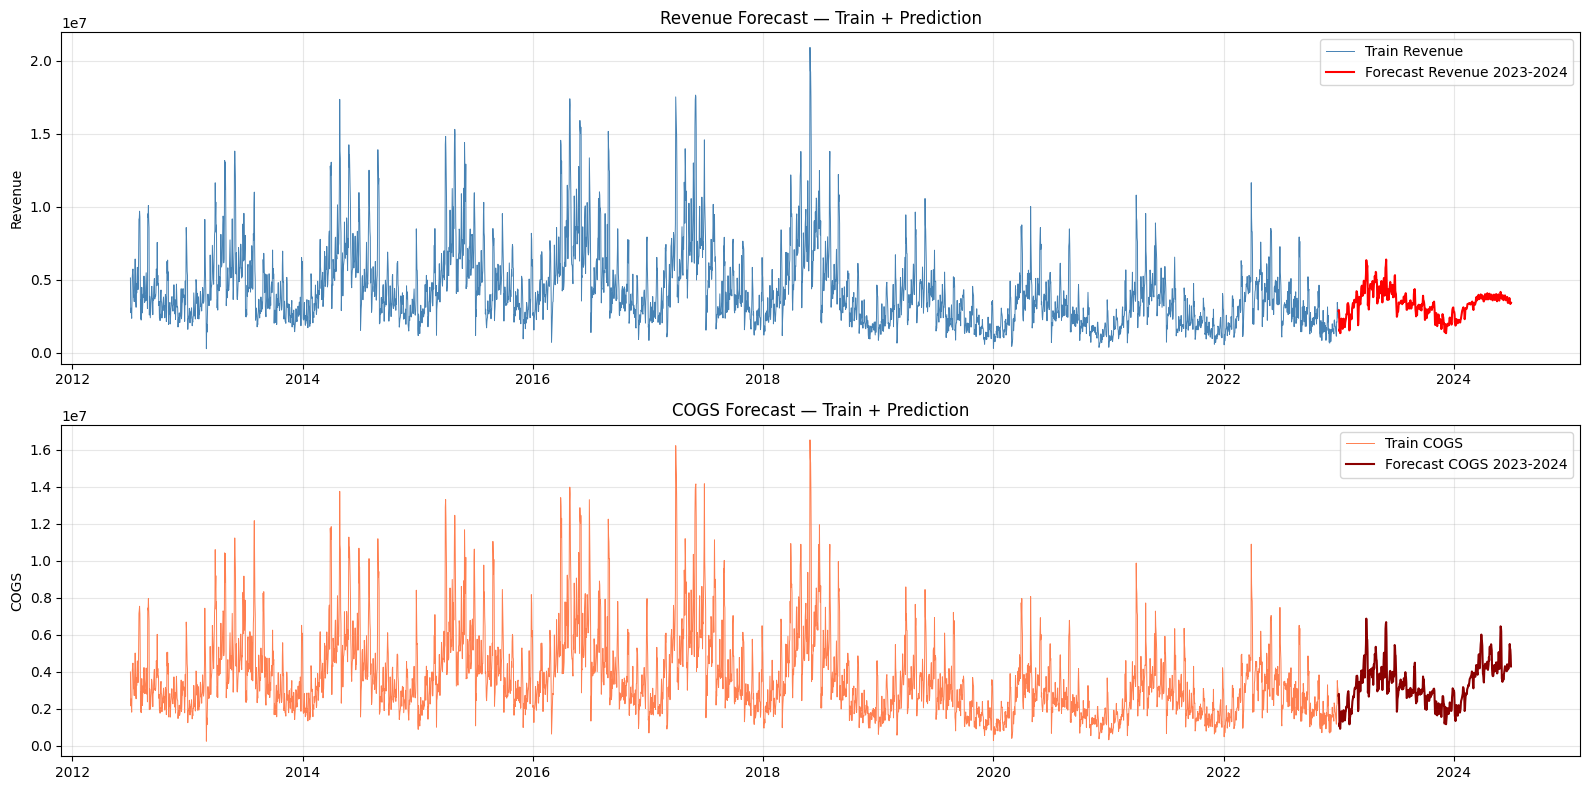

In [62]:
## ── Cell 15: Visualise forecasts ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

# Revenue
axes[0].plot(sales["Date"], sales["Revenue"], color="steelblue", lw=0.7, label="Train Revenue")
axes[0].plot(sub["Date"], rev_preds, color="red", lw=1.5, label="Forecast Revenue 2023-2024")
axes[0].set_title("Revenue Forecast — Train + Prediction")
axes[0].set_ylabel("Revenue")
axes[0].legend(); axes[0].grid(alpha=0.3)

# COGS
axes[1].plot(sales["Date"], sales["COGS"], color="coral", lw=0.7, label="Train COGS")
axes[1].plot(sub["Date"], cogs_preds, color="darkred", lw=1.5, label="Forecast COGS 2023-2024")
axes[1].set_title("COGS Forecast — Train + Prediction")
axes[1].set_ylabel("COGS")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../reports/figures/forecast_output.png", dpi=150)
plt.show()


## Giai đoạn 7 — Feature Importance & Explainability (SHAP)


Top 20 features (avg Model A + B):


,feature,importance_A,importance_B,importance_avg
38,prophet_Revenue_weekly,460,385,422.5
12,COGS_lag365,410,421,415.5
9,Revenue_lag366,390,370,380.0
37,prophet_Revenue_trend,392,331,361.5
14,Revenue_rstd7,416,300,358.0
25,Revenue_norm30,404,310,357.0
13,Revenue_rmean7,406,301,353.5
1,Revenue_lag14,342,345,343.5
7,Revenue_lag364,348,321,334.5
5,Revenue_lag90,353,306,329.5


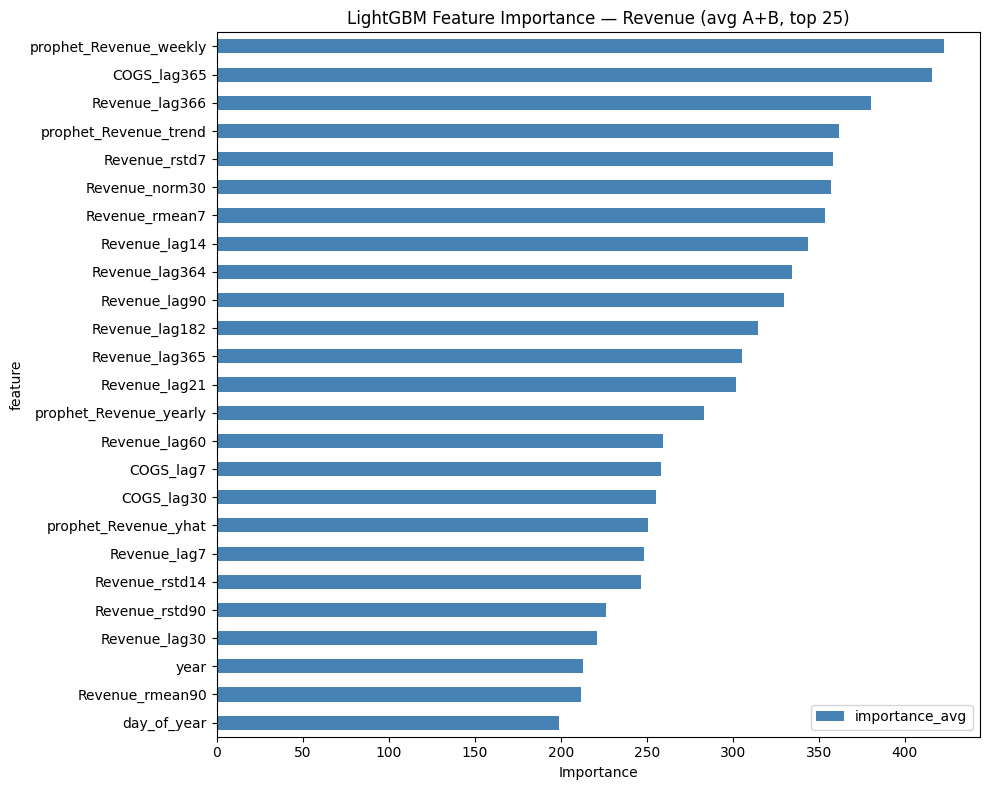

In [63]:
## ── Cell 16: Feature Importance (LightGBM native) ──────────────────────────
import pandas as pd

fi = pd.DataFrame({
    "feature": feat_cols_rev,
    "importance_A": lgbm_A.feature_importances_,
    "importance_B": lgbm_B.feature_importances_,
}).assign(
    importance_avg=lambda x: 0.5 * x["importance_A"] + 0.5 * x["importance_B"]
).sort_values("importance_avg", ascending=False)

print("Top 20 features (avg Model A + B):")
display(fi.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
fi.head(25).sort_values("importance_avg").plot.barh(
    x="feature", y="importance_avg", ax=ax, color="steelblue"
)
ax.set_title("LightGBM Feature Importance — Revenue (avg A+B, top 25)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance_revenue.png", dpi=150)
plt.show()


In [64]:
## ── Cell 17: SHAP explanation (optional — requires shap library) ─────────────
try:
    import shap
    shap_available = True
except ImportError:
    shap_available = False
    print("⚠️ SHAP not installed — run: pip install shap")

if shap_available:
    X_explain = df_train_full.loc[mask_final_tr, feat_cols_rev].fillna(0)
    # Use 500 random samples for speed
    X_sample = X_explain.sample(500, random_state=SEED)

    explainer = shap.TreeExplainer(lgbm_A)
    shap_values = explainer.shap_values(X_sample)

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
    plt.title("SHAP Feature Importance — Revenue Model A (LightGBM)")
    plt.tight_layout()
    plt.savefig("../reports/figures/shap_summary_revenue.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
    plt.title("SHAP Beeswarm — Revenue Model A")
    plt.tight_layout()
    plt.show()


⚠️ SHAP not installed — run: pip install shap


## Giai đoạn 8 — Tạo file nộp bài (submission.csv)
Format: `Date,Revenue,COGS` — đúng thứ tự như `sample_submission.csv`.


In [65]:
## ── Cell 18: Build & save submission.csv ─────────────────────────────────────
submission = sub[["Date"]].copy()
submission["Revenue"] = np.round(rev_preds, 2)
submission["COGS"]    = np.round(cogs_preds, 2)

# Sanity checks
assert len(submission) == len(sub), "Row count mismatch!"
assert (submission["Date"] == sub["Date"]).all(), "Date order mismatch!"
assert (submission["Revenue"] >= 0).all(), "Negative Revenue predictions!"
assert (submission["COGS"] >= 0).all(), "Negative COGS predictions!"

# Save
OUT_DIR = Path("../data/output")
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "submission_strategic_pipeline.csv"
submission.to_csv(out_path, index=False, date_format="%Y-%m-%d")

print(f"✓ Saved {out_path}")
print(f"  Rows        : {len(submission)}")
print(f"  Revenue     : {submission['Revenue'].min():,.2f} → {submission['Revenue'].max():,.2f}")
print(f"  COGS        : {submission['COGS'].min():,.2f} → {submission['COGS'].max():,.2f}")
display(submission.head(10))


✓ Saved ..\data\output\submission_strategic_pipeline.csv
  Rows        : 548
  Revenue     : 1,341,064.96 → 6,384,332.15
  COGS        : 907,129.84 → 6,867,302.54


,Date,Revenue,COGS
0,2023-01-01,2863722.48,2701191.69
1,2023-01-02,2930500.53,2797552.66
2,2023-01-03,2627907.55,2188868.16
3,2023-01-04,1465405.59,1025102.86
4,2023-01-05,1638262.79,1231381.24
5,2023-01-06,1343671.24,907129.84
6,2023-01-07,1357304.74,1136158.60
7,2023-01-08,1813904.81,1442740.96
8,2023-01-09,2178826.08,1756680.81
9,2023-01-10,2339859.53,1859817.77


In [66]:
## ── Cell 19: Save models to disk ────────────────────────────────────────────
import joblib
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(lgbm_A, MODEL_DIR / "strategic_lgbm_A_revenue.joblib")
joblib.dump(xgb_A,  MODEL_DIR / "strategic_xgb_A_revenue.joblib")
joblib.dump(lgbm_B, MODEL_DIR / "strategic_lgbm_B_revenue.joblib")
joblib.dump(xgb_B,  MODEL_DIR / "strategic_xgb_B_revenue.joblib")
joblib.dump(lgbm_cogs, MODEL_DIR / "strategic_lgbm_cogs.joblib")
joblib.dump(xgb_cogs,  MODEL_DIR / "strategic_xgb_cogs.joblib")

# Save blend weights and feature columns
meta = {
    "opt_weights"    : opt_weights.tolist(),
    "feat_cols_rev"  : feat_cols_rev,
    "feat_cols_cogs" : feat_cols_cogs,
    "alpha_weight"   : ALPHA_WEIGHT,
    "seed"           : SEED,
}
with open(MODEL_DIR / "strategic_pipeline_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("All models & metadata saved to models/")


All models & metadata saved to models/


## Giai đoạn 9 — Naive Baselines (Benchmark)
Theo ghi chú kinh nghiệm: **seasonal-naive(364)** thường rất mạnh.  
So sánh với ensemble để xác nhận mô hình thực sự mang lại cải thiện.


In [67]:
## ── Cell 20: Naive baselines on val2022H2 ────────────────────────────────────
val_dates = df_train_full.loc[mask_final_val, "Date"].tolist()
y_val_arr = df_train_full.loc[mask_final_val, "Revenue"].values
sales_idx = sales.set_index("Date")["Revenue"]

# Naive-364: use same day last year
naive_364 = np.array([
    sales_idx.get(dt - pd.Timedelta(days=364), np.nan) for dt in val_dates
])

# Naive-7: use same weekday last week
naive_7 = np.array([
    sales_idx.get(dt - pd.Timedelta(days=7), np.nan) for dt in val_dates
])

mask_valid = ~np.isnan(naive_364) & ~np.isnan(naive_7)
print(f"Valid naive predictions: {mask_valid.sum()}/{len(val_dates)}")

evaluate(y_val_arr[mask_valid], naive_364[mask_valid], "Naive-364 (same day -1y)")
evaluate(y_val_arr[mask_valid], naive_7[mask_valid],   "Naive-7   (same weekday)")
evaluate(y_val_arr[mask_valid],
         lgbm_A.predict(X_A_val)[mask_valid], "LGBM_A    (Model A)")
evaluate(y_val_arr[mask_valid],
         blend_pred_val[mask_valid], "Blend     (optimised)")


Valid naive predictions: 184/184
Naive-364 (same day -1y)        MAE=762,852  RMSE=1,073,553  R²=0.2505
Naive-7   (same weekday)        MAE=1,123,502  RMSE=1,634,102  R²=-0.7365
LGBM_A    (Model A)             MAE=584,958  RMSE=842,094  R²=0.5389
Blend     (optimised)           MAE=579,792  RMSE=837,689  R²=0.5437


{'mae': 579792.0577690593,
 'rmse': np.float64(837689.1263429419),
 'r2': 0.543667440441193}

---
## Tóm tắt Pipeline

| Bước | Mô tả |
|------|-------|
| 1 | Load `sales.csv`, EDA nhanh |
| 2 | Feature engineering: 10 lags, rolling stats 7/14/30/60/90d, calendar features |
| 3 | Prophet extractor: trend + weekly/yearly seasonality → features cho LGBM |
| 4 | Sample weighting: `exp(0.3*(year-2012))` xử lý structural break |
| 5 | Expanding window CV (4 folds × 6 tháng) |
| 6 | Model A (full 2012-2022 + weighting) + Model B (rolling 2019-2022) |
| 7 | Blend weight optimisation bằng Nelder-Mead trên val2022H2 |
| 8 | Recursive 548-step forecast cho Revenue + COGS |
| 9 | Benchmark vs naive-364 và naive-7 |
| 10 | Export `submission_strategic_pipeline.csv` + save models |

**Nếu muốn cải thiện thêm:**
- Tích hợp features từ `orders.csv` (daily_order_count) và `web_traffic.csv` (sessions) theo hướng dẫn trong pipeline
- Tune `alpha_weight` và hyperparameters bằng Optuna với TimeSeriesSplit
- Thêm SARIMA/ETS làm thành phần thứ 3 trong blend
